In [44]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [45]:
# --- Original Setup ---
df1 = pd.read_csv(r"C:\Users\Utkarsha\Downloads\diabetes.csv")

In [46]:
# Display initial rows and dataset summary
print("--- First 5 rows ---")
display(df1.head())

--- First 5 rows ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [47]:
print("\n--- Dataset Description ---")
display(df1.describe())


--- Dataset Description ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


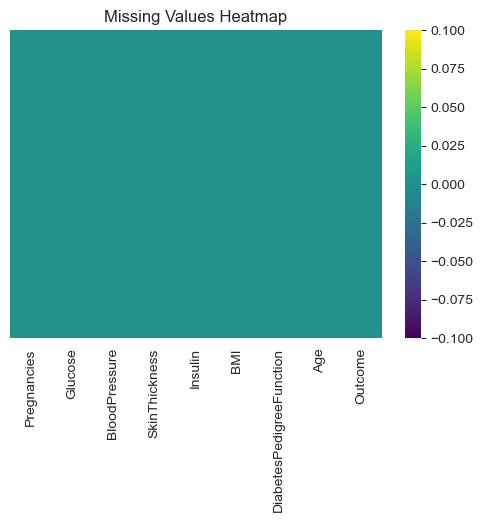

In [48]:
# Check missing values via heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df1.isnull(), yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [49]:
def check_zero_values(df):
    """
    Checks for columns where a value of 0 acts as a missing/invalid placeholder.
    """
    cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    zero_counts = {col: (df[col] == 0).sum() for col in cols_with_zeros}
    zero_df = pd.DataFrame(list(zero_counts.items()), columns=['Feature', 'Zero_Count'])
    return zero_df

In [50]:
def plot_correlation_heatmap(df):
    """
    Plots a heatmap showing the correlation matrix of all features.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Diabetes Dataset', fontsize=14)
    plt.tight_layout()
    plt.show()

In [51]:
def plot_feature_distribution(df, feature_name):
    """
    Plots the histogram and KDE distribution of a specific feature split by Outcome.
    """
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature_name, hue='Outcome', kde=True, bins=30, palette='Set1')
    plt.title(f'Distribution of {feature_name} by Diabetes Outcome', fontsize=14)
    plt.xlabel(feature_name)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [52]:
def get_summary_by_outcome(df):
    """
    Calculates the mean of all features grouped by the diabetes Outcome.
    """
    summary = df.groupby('Outcome').mean().T
    summary.columns = ['Non-Diabetic (0)', 'Diabetic (1)']
    return summary


--- 1. Invalid Zero-Value Check ---


,Feature,Zero_Count
0,Glucose,5
1,BloodPressure,35
2,SkinThickness,227
3,Insulin,374
4,BMI,11



--- 2. Summary Statistics by Outcome ---


,Non-Diabetic (0),Diabetic (1)
Pregnancies,3.298000,4.865672
Glucose,109.980000,141.257463
BloodPressure,68.184000,70.824627
SkinThickness,19.664000,22.164179
Insulin,68.792000,100.335821
BMI,30.304200,35.142537
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164



--- 3. Generating Correlation Heatmap ---


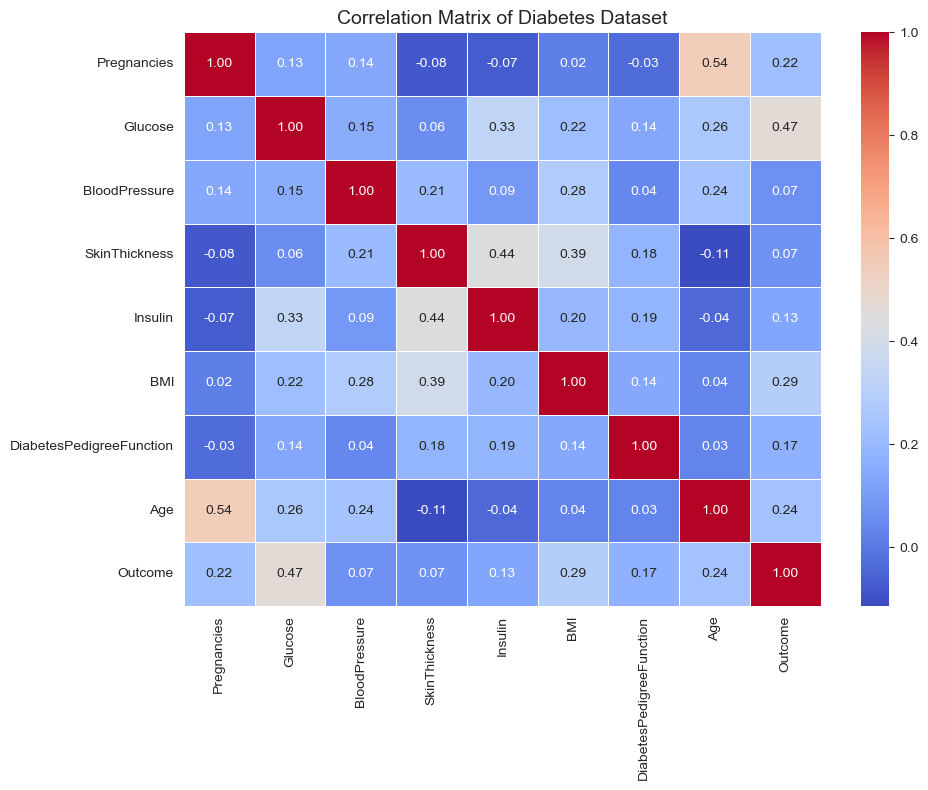


--- 4. Generating Feature Distribution Plot (e.g., Glucose) ---


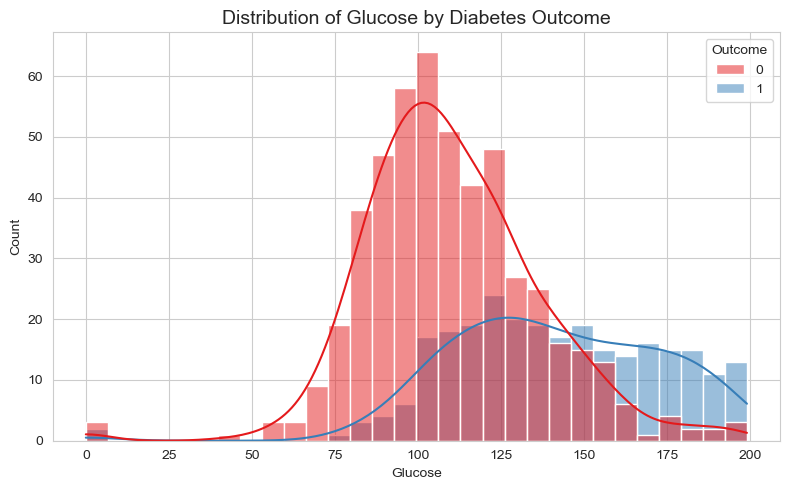

In [53]:
print("\n--- 1. Invalid Zero-Value Check ---")
display(check_zero_values(df1))

print("\n--- 2. Summary Statistics by Outcome ---")
display(get_summary_by_outcome(df1))

print("\n--- 3. Generating Correlation Heatmap ---")
plot_correlation_heatmap(df1)

print("\n--- 4. Generating Feature Distribution Plot (e.g., Glucose) ---")
plot_feature_distribution(df1, 'Glucose')